In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/training_v2.csv')

# Select our features
pulse_features = [
    'hospital_death',
    'age', 'gender', 'weight', 'height', 'bmi',
    'elective_surgery', 'icu_type', 'icu_admit_source',
    'd1_heartrate_max', 'd1_heartrate_min',
    'd1_sysbp_max', 'd1_sysbp_min',
    'd1_diasbp_max', 'd1_diasbp_min',
    'd1_mbp_max', 'd1_mbp_min',
    'd1_resprate_max', 'd1_resprate_min',
    'd1_spo2_max', 'd1_spo2_min',
    'd1_temp_max', 'd1_temp_min',
    'd1_lactate_max', 'd1_lactate_min',
    'd1_creatinine_max', 'd1_creatinine_min',
    'd1_wbc_max', 'd1_wbc_min',
    'd1_hemaglobin_max', 'd1_hemaglobin_min',
    'd1_glucose_max', 'd1_glucose_min',
    'd1_bun_max', 'd1_bun_min',
    'd1_sodium_max', 'd1_sodium_min',
    'd1_potassium_max', 'd1_potassium_min',
    'apache_4a_hospital_death_prob',
    'apache_4a_icu_death_prob',
    'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache',
    'heart_rate_apache', 'map_apache', 'temp_apache',
    'creatinine_apache', 'bun_apache', 'wbc_apache',
    'aids', 'cirrhosis', 'diabetes_mellitus',
    'hepatic_failure', 'immunosuppression',
    'solid_tumor_with_metastasis'
]

df_pulse = df[pulse_features].copy()
print("Dataset loaded:", df_pulse.shape)
print("Done ✅")

Dataset loaded: (91713, 56)
Done ✅


In [2]:
# Step 1 - Fill missing values

# For lactate - high missing (74%) - fill with median
# (lactate not tested = patient likely stable, use median)
lactate_cols = ['d1_lactate_max', 'd1_lactate_min']
for col in lactate_cols:
    df_pulse[col].fillna(df_pulse[col].median(), inplace=True)

# For all other numeric columns - fill with median
numeric_cols = df_pulse.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if col != 'hospital_death':
        df_pulse[col].fillna(df_pulse[col].median(), inplace=True)

# For categorical columns - fill with mode
categorical_cols = ['gender', 'icu_type', 'icu_admit_source']
for col in categorical_cols:
    df_pulse[col].fillna(df_pulse[col].mode()[0], inplace=True)

# Verify no missing values remain
total_missing = df_pulse.isnull().sum().sum()
print(f"Total missing values remaining: {total_missing}")
print("Missing values handled ✅")

Total missing values remaining: 391278
Missing values handled ✅


In [3]:
# Check which columns still have missing values
still_missing = df_pulse.isnull().sum()
still_missing = still_missing[still_missing > 0]
print("Columns still missing:")
print(still_missing)
print("\nTotal columns with missing:", len(still_missing))

Columns still missing:
age                               4228
gender                              25
weight                            2720
height                            1334
bmi                               3429
icu_admit_source                   112
d1_heartrate_max                   145
d1_heartrate_min                   145
d1_sysbp_max                       159
d1_sysbp_min                       159
d1_diasbp_max                      165
d1_diasbp_min                      165
d1_mbp_max                         220
d1_mbp_min                         220
d1_resprate_max                    385
d1_resprate_min                    385
d1_spo2_max                        333
d1_spo2_min                        333
d1_temp_max                       2324
d1_temp_min                       2324
d1_lactate_max                   68396
d1_lactate_min                   68396
d1_creatinine_max                10169
d1_creatinine_min                10169
d1_wbc_max                       13174
d1

In [4]:
# Fix - force fill all remaining missing values

# Separate numeric and categorical
numeric_cols = df_pulse.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_pulse.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", categorical_cols)

# Fill numeric with median
for col in numeric_cols:
    if col != 'hospital_death':
        median_val = df_pulse[col].median()
        df_pulse[col] = df_pulse[col].fillna(median_val)

# Fill categorical with mode
for col in categorical_cols:
    mode_val = df_pulse[col].mode()[0]
    df_pulse[col] = df_pulse[col].fillna(mode_val)

# Verify
total_missing = df_pulse.isnull().sum().sum()
print(f"\nTotal missing values remaining: {total_missing}")

if total_missing == 0:
    print("All missing values handled ✅")
else:
    print("Still missing in:")
    print(df_pulse.isnull().sum()[df_pulse.isnull().sum() > 0])

Numeric columns: 53
Categorical columns: ['gender', 'icu_type', 'icu_admit_source']

Total missing values remaining: 0
All missing values handled ✅


In [5]:
# Feature Engineering - create new clinically meaningful features

# 1. Shock Index = heart_rate / systolic_bp
# High shock index = patient in shock
df_pulse['shock_index'] = df_pulse['d1_heartrate_max'] / df_pulse['d1_sysbp_min'].replace(0, np.nan)

# 2. Pulse Pressure = systolic_bp - diastolic_bp
# Narrow pulse pressure = poor cardiac output
df_pulse['pulse_pressure'] = df_pulse['d1_sysbp_max'] - df_pulse['d1_diasbp_min']

# 3. GCS Total = eyes + motor + verbal
# Lower score = less conscious = more dangerous
df_pulse['gcs_total'] = (df_pulse['gcs_eyes_apache'] + 
                          df_pulse['gcs_motor_apache'] + 
                          df_pulse['gcs_verbal_apache'])

# 4. Heart rate range = max - min (variability signal)
df_pulse['heartrate_range'] = df_pulse['d1_heartrate_max'] - df_pulse['d1_heartrate_min']

# 5. BP range = systolic max - systolic min (variability signal)
df_pulse['sysbp_range'] = df_pulse['d1_sysbp_max'] - df_pulse['d1_sysbp_min']

# 6. SpO2 range = max - min (dropping oxygen signal)
df_pulse['spo2_range'] = df_pulse['d1_spo2_max'] - df_pulse['d1_spo2_min']

# 7. Temp range = max - min (fever/hypothermia signal)
df_pulse['temp_range'] = df_pulse['d1_temp_max'] - df_pulse['d1_temp_min']

# 8. BUN to Creatinine ratio (kidney function)
df_pulse['bun_creatinine_ratio'] = df_pulse['d1_bun_max'] / df_pulse['d1_creatinine_max'].replace(0, np.nan)

# 9. Age groups (risk increases with age)
df_pulse['age_group'] = pd.cut(df_pulse['age'], 
                                bins=[0, 40, 60, 75, 100], 
                                labels=[0, 1, 2, 3]).astype(float)

# 10. High lactate flag (lactate > 2.0 = tissue hypoxia)
df_pulse['high_lactate_flag'] = (df_pulse['d1_lactate_max'] > 2.0).astype(int)

# Fill any NaN created by division
new_features = ['shock_index', 'pulse_pressure', 'gcs_total', 
                'heartrate_range', 'sysbp_range', 'spo2_range',
                'temp_range', 'bun_creatinine_ratio', 'age_group',
                'high_lactate_flag']

for col in new_features:
    df_pulse[col] = df_pulse[col].fillna(df_pulse[col].median())

print("New features created:")
for f in new_features:
    print(f"  ✅ {f}")

print(f"\nDataset shape after feature engineering: {df_pulse.shape}")

New features created:
  ✅ shock_index
  ✅ pulse_pressure
  ✅ gcs_total
  ✅ heartrate_range
  ✅ sysbp_range
  ✅ spo2_range
  ✅ temp_range
  ✅ bun_creatinine_ratio
  ✅ age_group
  ✅ high_lactate_flag

Dataset shape after feature engineering: (91713, 66)


In [6]:
# Encode categorical columns
le = LabelEncoder()

categorical_cols = ['gender', 'icu_type', 'icu_admit_source']
for col in categorical_cols:
    df_pulse[col] = le.fit_transform(df_pulse[col])
    print(f"✅ Encoded: {col}")

# Verify all columns are numeric now
non_numeric = df_pulse.select_dtypes(include=['object']).columns.tolist()
print(f"\nNon-numeric columns remaining: {non_numeric}")

# Final dataset summary
print(f"\nFinal dataset shape: {df_pulse.shape}")
print(f"Total features: {df_pulse.shape[1] - 1}")
print(f"Target column: hospital_death")
print(f"\nFeature list:")
for i, col in enumerate(df_pulse.columns.tolist()):
    if col != 'hospital_death':
        print(f"  {i+1}. {col}")

✅ Encoded: gender
✅ Encoded: icu_type
✅ Encoded: icu_admit_source

Non-numeric columns remaining: []

Final dataset shape: (91713, 66)
Total features: 65
Target column: hospital_death

Feature list:
  2. age
  3. gender
  4. weight
  5. height
  6. bmi
  7. elective_surgery
  8. icu_type
  9. icu_admit_source
  10. d1_heartrate_max
  11. d1_heartrate_min
  12. d1_sysbp_max
  13. d1_sysbp_min
  14. d1_diasbp_max
  15. d1_diasbp_min
  16. d1_mbp_max
  17. d1_mbp_min
  18. d1_resprate_max
  19. d1_resprate_min
  20. d1_spo2_max
  21. d1_spo2_min
  22. d1_temp_max
  23. d1_temp_min
  24. d1_lactate_max
  25. d1_lactate_min
  26. d1_creatinine_max
  27. d1_creatinine_min
  28. d1_wbc_max
  29. d1_wbc_min
  30. d1_hemaglobin_max
  31. d1_hemaglobin_min
  32. d1_glucose_max
  33. d1_glucose_min
  34. d1_bun_max
  35. d1_bun_min
  36. d1_sodium_max
  37. d1_sodium_min
  38. d1_potassium_max
  39. d1_potassium_min
  40. apache_4a_hospital_death_prob
  41. apache_4a_icu_death_prob
  42. gcs_eyes

Saved successfully ✅
Shape: (91713, 66)
Missing values: 0
Target distribution:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


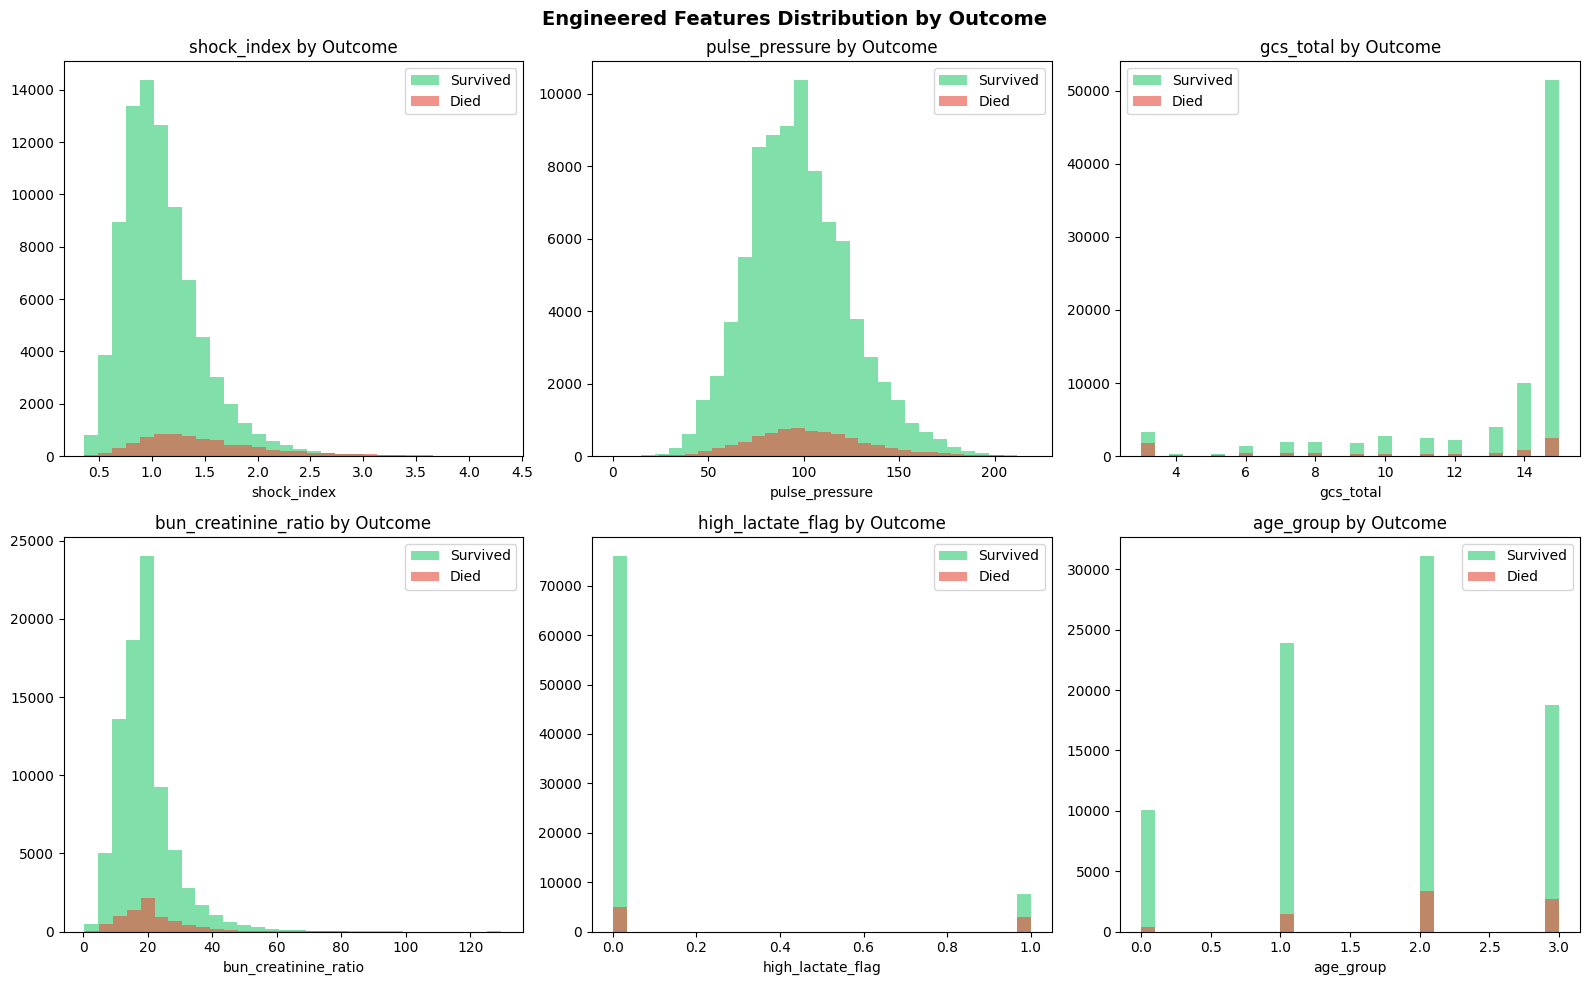


Notebook 02 - Feature Engineering COMPLETE ✅
Clean dataset saved to: data/pulsealert_clean.csv


In [7]:
# Save clean dataset for model training
df_pulse.to_csv('../data/pulsealert_clean.csv', index=False)

# Quick final verification
df_check = pd.read_csv('../data/pulsealert_clean.csv')
print(f"Saved successfully ✅")
print(f"Shape: {df_check.shape}")
print(f"Missing values: {df_check.isnull().sum().sum()}")
print(f"Target distribution:")
print(df_check['hospital_death'].value_counts())

# Visualize new engineered features vs outcome
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

eng_features = [
    'shock_index', 'pulse_pressure', 'gcs_total',
    'bun_creatinine_ratio', 'high_lactate_flag', 'age_group'
]

for i, col in enumerate(eng_features):
    for outcome, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Survived', 'Died']):
        data = df_check[df_check['hospital_death'] == outcome][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=label)
    axes[i].set_title(f'{col} by Outcome')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.suptitle('Engineered Features Distribution by Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNotebook 02 - Feature Engineering COMPLETE ✅")
print("Clean dataset saved to: data/pulsealert_clean.csv")